In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib widget

alpha: 0.3, beta: 0.965, gamma: 0.034999999999999996


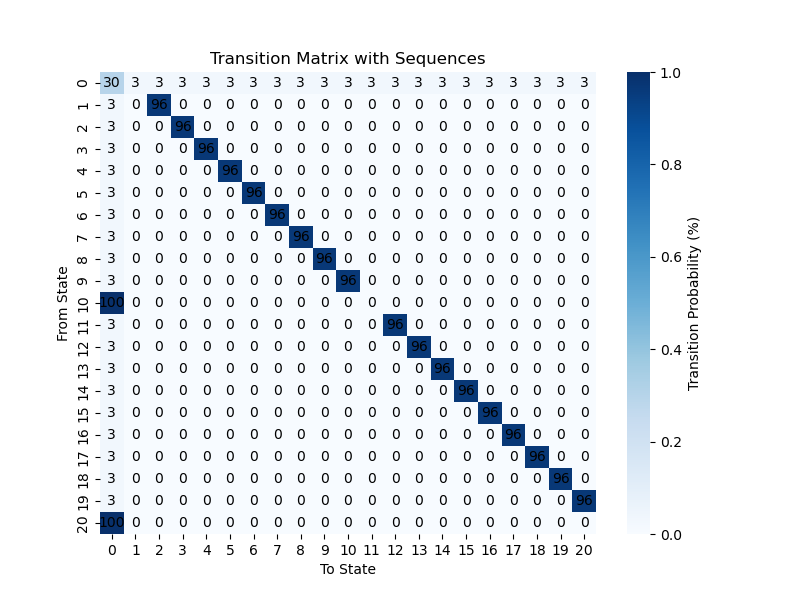

In [77]:
# make a transition matrix with a different structure and see if we can recover it

alpha = 0.3 # this is the probability of staying in the non sequence state. This is the only free parameter we have to set, the rest of the transition probabilities are determined by this and the sequence length and number of sequences
sequenceLength = 10 # number of latent states in each sequence
nSequences = 2 # total number of sequences

def calculate_transition_matrix(alpha, sequenceLength, nSequences):

    # the total number of states is the number of sequences times the sequence length and we add one for the non-sequence state
    nStates = sequenceLength * nSequences + 1

    gamma = (1 - alpha) / (nStates - 1) # this is the probability of transitioning into or out of any of the sequence states
    beta = 1 - gamma # this is the probability of transitioning between states in the sequence
    print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}")

    # initialize the transition matrix with zeros and then fill in the appropriate entries
    P = np.zeros((nStates, nStates))
    P[0, 0] = alpha



    # define the transition probabilities into the sequences (can transition into any part of the sequence with equal probability)
    P[0, 1:] = gamma

    # define the transition probabilities out of the sequences (can transition out of any part of the sequence with equal probability)
    P[1:, 0] = gamma


    # define the transition probabilities through the sequences
    for i in range(nSequences):
        start = 1 + i * sequenceLength
        end = start + sequenceLength
        for j in range(start, end):
            if j == end - 1:
                P[j, 0] = 1 # transition from the last state in the sequence back to the non-sequence state
            else:
                P[j, j + 1] = beta # transition from one state in the sequence to the next state in the sequence

    return P

P = calculate_transition_matrix(alpha, sequenceLength, nSequences)
nStates = P.shape[0]



plt.figure(figsize=(8, 6))
sns.heatmap(P, cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1)
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        plt.text(j + 0.5, i + 0.5, f"{(P[i, j] * 100):.0f}", ha="center", va="center", color="black")
plt.title("Transition Matrix with Sequences")
plt.xlabel("To State")
plt.ylabel("From State")

plt.show()

In [32]:
# simulate data from this transition matrix
Nsteps = 50000
states = np.zeros(Nsteps, dtype=int)
for t in range(1, Nsteps):
    states[t] = np.random.choice(nStates, p=P[states[t-1]])

(21, 500)


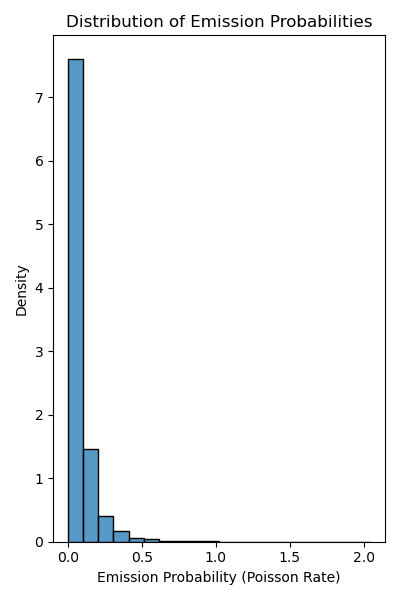

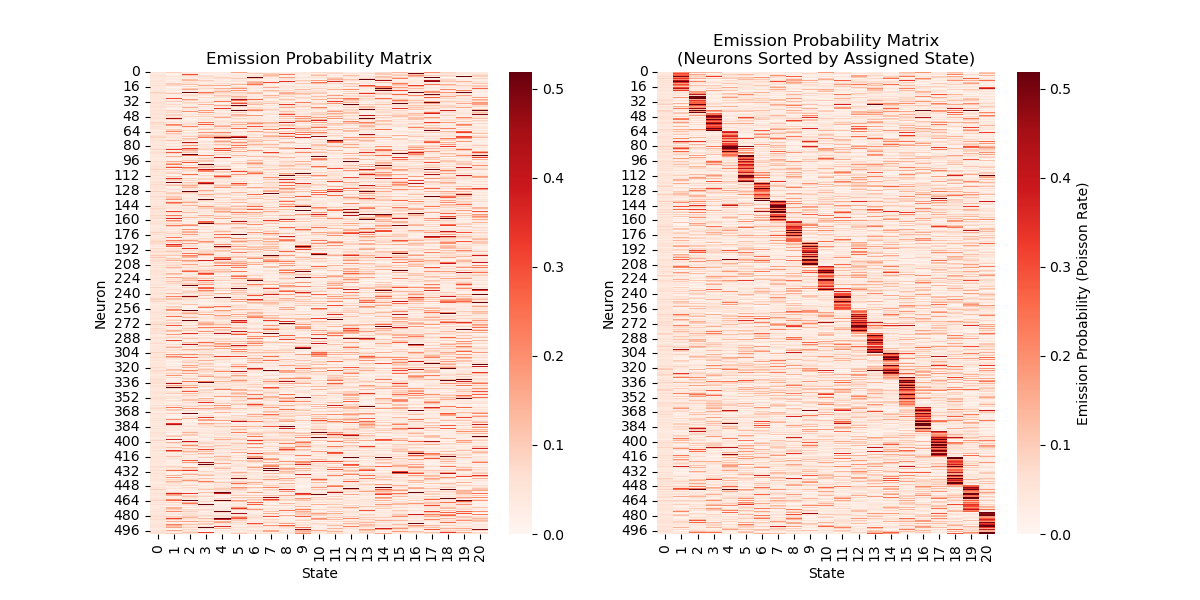

In [70]:
plot_len = 100

# randomly initialize the emission probabilities (poisson rates for each state and each neuron)
emission_dim = 500 # this corresponds to the number of neurons we are simulating

# draw the lambda parameters for the Poisson emissions from a lognormal distribution (this is a common choice for a prior on Poisson rates)
emission_prob = np.random.lognormal(mean=-3, sigma=1, size=(nStates, emission_dim))
print(emission_prob.shape)
    
# set the emission prob in state zero to be the median across all the other states
emission_prob[0, :] = np.median(emission_prob[1:, :], axis=0)

# plot the distribution of emission probabilities for each state
plt.figure(figsize=(4, 6))
sns.histplot(emission_prob.flatten(), bins=20, stat='density')
plt.title("Distribution of Emission Probabilities")
plt.xlabel("Emission Probability (Poisson Rate)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# simulate emissions from the HMM given the state sequence and the emission probabilities
emissions = np.zeros((Nsteps, emission_dim), dtype=int)
for t in range(Nsteps):
    emissions[t] = np.random.poisson(lam=emission_prob[states[t]])


# plot the emission prob matrix
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(emission_prob.T, cmap="Reds", ax=axs[0], vmin=0, vmax=np.percentile(emission_prob, 99))
axs[0].set_title("Emission Probability Matrix")
axs[0].set_xlabel("State")
axs[0].set_ylabel("Neuron")

# assign neurons to states (for each neuron, the state of maximal firing is the state that neuron is assigned to)
neuron_states = np.argmax(emission_prob, axis=0)

# sort the neurons by their assigned states and plot the emision prob matrix again
sorted_indices = np.argsort(neuron_states)
sns.heatmap(emission_prob[:, sorted_indices].T, cmap="Reds", ax=axs[1], cbar_kws={"label": "Emission Probability (Poisson Rate)"}, vmin=0, vmax=np.percentile(emission_prob, 99))
axs[1].set_title("Emission Probability Matrix\n(Neurons Sorted by Assigned State)")
axs[1].set_xlabel("State")
axs[1].set_ylabel("Neuron")
plt.show()



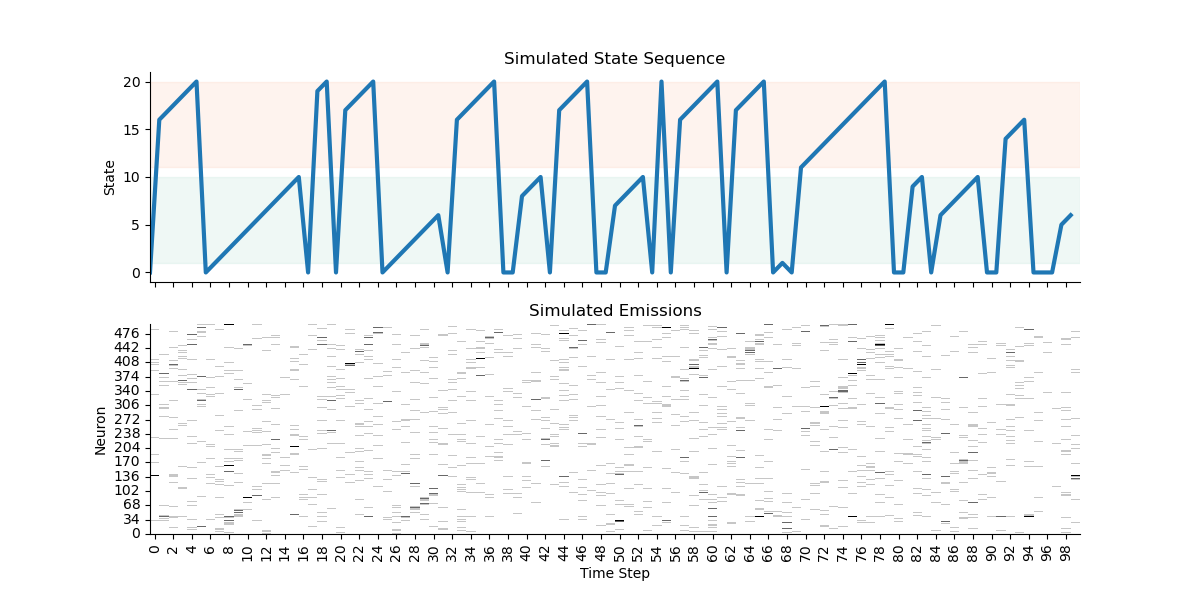

In [71]:
seq_colors = sns.color_palette("Set2", nSequences)


# sort the neurons by their assigned states and plot the emissions again
sorted_indices = np.argsort(neuron_states)
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sns.lineplot(x=np.arange(plot_len), y=states[:plot_len], ax=axs[0], linewidth=3)
axs[0].set_title("Simulated State Sequence")
axs[0].set_ylabel("State")
sns.heatmap(emissions[:plot_len, sorted_indices].T, cmap="Greys", ax=axs[1], vmax = 3)
# flip the y axis so that neuron 0 is at the bottom and neuron 19 is at the top
axs[1].invert_yaxis()
axs[1].set_title("Simulated Emissions")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Neuron")
# remove colorbar
axs[1].collections[0].colorbar.remove()

# shade the regions of the plot corresponding to the sequences
for i in range(nSequences):
    start = 1 + i * sequenceLength
    end = start + sequenceLength
    axs[0].axhspan(start, end - 1, color = seq_colors[i], alpha=0.1)

sns.despine()
plt.show()



In [79]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from dynamax.hidden_markov_model import PoissonHMM
from scipy.optimize import minimize_scalar
import seaborn as sns
import numpy as np

In [83]:
def make_folds(T, n_folds):
    indices = np.arange(T)
    return np.array_split(indices, n_folds)


def cv_objective(
    alpha,
    sequence_length,
    n_sequences,
    emissions,
    folds,
    num_iters=50,
    n_restarts=3
):

    fold_scores = []

    for fold_idx in range(len(folds)):

        test_idx = folds[fold_idx]

        train_idx = np.setdiff1d(
            np.arange(len(emissions)),
            test_idx
        )

        train_emissions = emissions[train_idx]
        test_emissions = emissions[test_idx]

        P = calculate_transition_matrix(
            alpha,
            sequence_length,
            n_sequences
        )

        nStates = P.shape[0]
        emission_dim = emissions.shape[1]

        best_ll = -np.inf

        # multiple EM restarts
        for seed in range(n_restarts):

            key = jr.PRNGKey(seed)

            hmm = PoissonHMM(
                nStates,
                emission_dim
            )

            # initialize emissions uniformly
            initial_rates = np.mean(
                train_emissions,
                axis=0,
                keepdims=True
            )

            initial_rates = np.repeat(
                initial_rates,
                nStates,
                axis=0
            )

            params, props = hmm.initialize(
                key,
                transition_matrix=P,
                emission_rates=initial_rates
            )

            # freeze transitions
            props.transitions.transition_matrix.trainable = False

            # EM fit
            params, lls = hmm.fit_em(
                params,
                props,
                train_emissions,
                num_iters=num_iters
            )

            # evaluate held-out likelihood
            test_ll = hmm.marginal_log_prob(
                params,
                test_emissions
            )

            if test_ll > best_ll:
                best_ll = test_ll

        fold_scores.append(best_ll)

    # negative because minimize_scalar minimizes
    return -np.mean(fold_scores)





In [ ]:
candidate_lengths = np.arange(5, 20)
candidate_sequences = np.arange(1, 5)

folds = make_folds(
    T=len(emissions),
    n_folds=5
)

best_score = -np.inf
best_model = None

for L in candidate_lengths:

    for S in candidate_sequences:

        print(f"Testing L={L}, S={S}")

        result = minimize_scalar(
            cv_objective,
            bounds=(0.1, 0.9),
            method='bounded',
            args=(L, S, emissions, folds)
        )

        alpha_hat = result.x
        score = -result.fun

        print(
            f"alpha={alpha_hat:.3f}, "
            f"CV log likelihood={score:.3f}"
        )

        if score > best_score:

            best_score = score

            best_model = {
                "sequence_length": L,
                "n_sequences": S,
                "alpha": alpha_hat,
                "score": score
            }

print("\nBest model:")
print(best_model)

Testing L=5, S=1
alpha: 0.4055728090000841, beta: 0.8811145618000168, gamma: 0.11888543819998318


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

alpha: 0.4055728090000841, beta: 0.8811145618000168, gamma: 0.11888543819998318


...

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

alpha: 0.4055728090000841, beta: 0.8811145618000168, gamma: 0.11888543819998318


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:12&lt;00:00]</div>

<div><progress max="50" value="0"></progress> 0.00% [0/50 00:00&lt;?]</div>

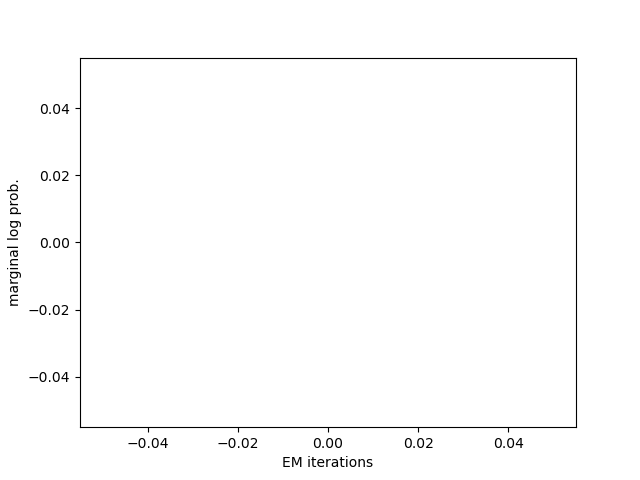

(50000, 21)


In [74]:
# Plot the marginal log probs across EM iterations
plt.figure()
plt.plot(lls)
plt.xlabel("EM iterations")
plt.ylabel("marginal log prob.")
plt.show()

# Use fitted model for posterior inference
post = hmm.smoother(params, emissions)
print(post.smoothed_probs.shape) # (100, 3)

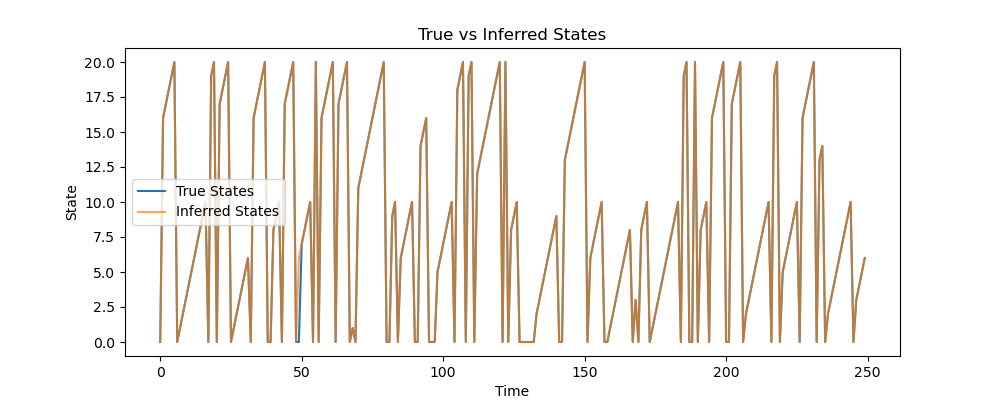

In [75]:
plot_len = 250

# plot the true and inferred states
plt.figure(figsize=(10, 4))
plt.plot(states[:plot_len], label="True States")
plt.plot(jnp.argmax(post.smoothed_probs, axis=1)[:plot_len], label="Inferred States", alpha=0.7)
plt.legend()
plt.xlabel("Time")
plt.ylabel("State")
plt.title("True vs Inferred States")
plt.show()

(21, 500)
[[0.03835744 0.04279408 0.03597728 ... 0.05509074 0.06914907 0.04484612]
 [0.08705108 0.02432398 0.00767567 ... 0.04592277 0.03600199 0.11325336]
 [0.032297   0.04220182 0.3132844  ... 0.07932113 0.12263004 0.06703558]
 ...
 [0.08022989 0.06561414 0.03938297 ... 0.09548594 0.3610695  0.02115857]
 [0.03995346 0.03183932 0.03703736 ... 0.02405002 0.16913056 0.05349009]
 [0.02796729 0.03879795 0.05632762 ... 0.00924459 0.07345876 0.04937381]]


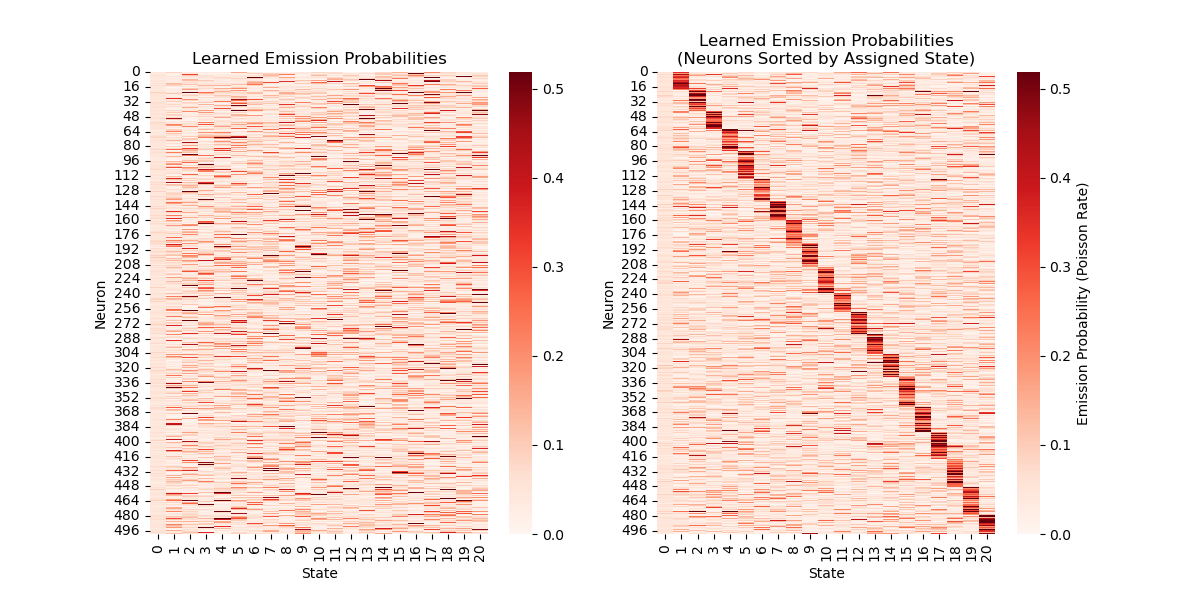

In [76]:
learned = params.emissions.rates
print(learned.shape) # (3, 20)
print(learned)

# plot the learned emission probabilities
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(learned.T, cmap="Reds", vmin=0, vmax=np.percentile(learned, 99), ax=axs[0])
axs[0].set_title("Learned Emission Probabilities")
axs[0].set_xlabel("State")
axs[0].set_ylabel("Neuron")

# sort the neurons by their assigned states and plot the learned emission probabilities again
neuron_states_learned = np.argmax(learned, axis=0)
sorted_indices_learned = np.argsort(neuron_states_learned)
sns.heatmap(learned[:, sorted_indices_learned].T, cmap="Reds", ax=axs[1], cbar_kws={"label": "Emission Probability (Poisson Rate)"}, vmin=0, vmax=np.percentile(learned, 99))
axs[1].set_title("Learned Emission Probabilities\n(Neurons Sorted by Assigned State)")
axs[1].set_xlabel("State")
axs[1].set_ylabel("Neuron")

plt.show()
